### Создание собственных распределений в Python

### Распределение по арксинусу
$\phi(x)=\frac{1}{\pi\sqrt{x(1-x)}}$\
\
$F(x)=\frac{2}{\pi}arcsin(\sqrt{x})$\
\
$G(q)=sin^{2}(\frac{\pi}{2}q)$\
\
$x\in [0, 1]$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous
from scipy import integrate

In [15]:
class Arcsin_Distribution(rv_continuous):
    def __init__(self, a, b):
        super().__init__(a=a, b=b, name='custom_dist')
    
    def _pdf(self, x):
        # плотность распределения
        result = np.zeros_like(x, dtype=float)
        mask = (x > self.a) & (x < self.b)
        result[mask] = 1 / (np.pi * np.sqrt(x[mask] * (1 - x[mask])))
        return result
    
    def _cdf(self, x):
        # функция распределения
        result = np.zeros_like(x)
        result[x <= self.a] = 0.0
        mask = (x > self.a) & (x < self.b)
        result[mask] = (2 / np.pi) * np.arcsin(np.sqrt(x[mask]))
        result[x >= self.b] = 1.0
        return result
    
    def _ppf(self, q):
        # Обратная функция распределения
        return (np.sin((np.pi / 2) * q)) ** 2
    
a, b = 0, 1
custom_dist = Arcsin_Distribution(a, b)

sample = custom_dist.rvs(size=10000)

print(f"Размер выборки: {len(sample)}")
print(f"Первые 10 значений: {sample[:10]}")

x_test = np.linspace(a, b, 1000)
pdf_values = custom_dist.pdf(x_test)
cdf_values = custom_dist.cdf(x_test)

print("Проверка нормировки плотности:")
integral, error = integrate.quad(custom_dist.pdf, a, b)
print(f"Интеграл плотности от {a} до {b}: {integral:.6f} (ошибка: {error:.2e})")

print("\nПроверка в граничных точках:")
print(f"F({a}) = {custom_dist.cdf(a):.6f}")
print(f"F({b}) = {custom_dist.cdf(b):.6f}")



Размер выборки: 10000
Первые 10 значений: [3.28762643e-01 9.99687236e-01 6.29883903e-04 9.97263858e-01
 8.89310041e-01 1.72018066e-01 2.32662998e-02 2.69012049e-03
 8.21004917e-01 8.46983843e-01]
Проверка нормировки плотности:
Интеграл плотности от 0 до 1: 1.000000 (ошибка: 1.98e-10)

Проверка в граничных точках:
F(0) = 0.000000
F(1) = 1.000000


In [16]:
print("Числовые характеристики:")
print(f"Математическое ожидание: {custom_dist.mean():.4f}")
print(f"Дисперсия: {custom_dist.var():.4f}")
print(f"Медиана: {custom_dist.median():.4f}")
print(f"Cтандартное отклонение: {custom_dist.std():.4f}")
print("Статистика — Среднее, Дисперсия, Асимметрия, Эксцесс:",
      *custom_dist.stats(moments='mvsk'),
      sep='\n\t')
print(f"25% квантиль: {custom_dist.ppf(0.25):.4f}")
print(f"75% квантиль: {custom_dist.ppf(0.75):.4f}")

Числовые характеристики:
Математическое ожидание: 0.5000
Дисперсия: 0.1250
Медиана: 0.5000
Cтандартное отклонение: 0.3536
Статистика — Среднее, Дисперсия, Асимметрия, Эксцесс:
	0.5
	0.12499999999999994
	3.768221900841063e-15
	-1.5000000000000129
25% квантиль: 0.1464
75% квантиль: 0.8536


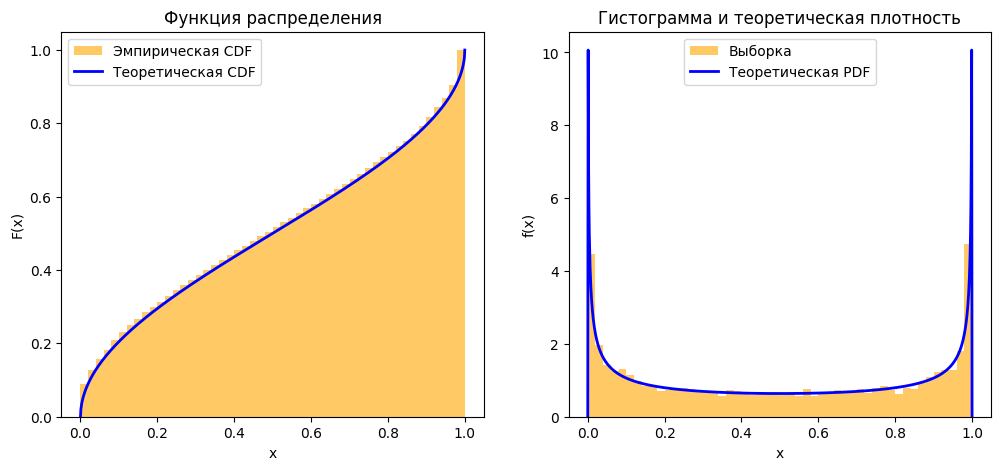

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x_plot = np.linspace(a, b, 1000)

ax1.hist(sample, bins=50, density=True, cumulative=True,
         alpha=0.6, color='orange', label='Эмпирическая CDF')
ax1.plot(x_plot, custom_dist.cdf(x_plot),
         'b-', lw=2, label='Теоретическая CDF')
ax1.set_xlabel('x')
ax1.set_ylabel('F(x)')
ax1.set_title('Функция распределения')
ax1.legend()

ax2.hist(sample, bins=50, density=True, 
         alpha=0.6, color='orange', label='Выборка')
ax2.plot(x_plot, custom_dist.pdf(x_plot), 'b-', linewidth=2, 
         label='Теоретическая PDF')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
ax2.set_title('Гистограмма и теоретическая плотность')
ax2.legend()

plt.show()
